In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import skops.io as sio
from utils import ASSETS_DIR

In [ ]:
# Pulizia csv da index e label
dataframe = pd.read_csv(f'{ASSETS_DIR}/seeds_11/train_11.csv')

dataframe = dataframe.drop(columns=['label'])

In [6]:
#dataframe = pd.read_csv('../assets/seeds_11/train_11.csv')  Deprecata, si prende sia label che indice csv
dataframe.head()
dataframe.info()
dataframe.describe()
X = dataframe.drop(columns=['label'])

<class 'pandas.DataFrame'>
Index: 87447 entries, 76152 to 106757
Columns: 512 entries, 0 to 511
dtypes: float64(512)
memory usage: 342.3 MB


,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
count,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,...,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000
mean,0.679764,0.849554,0.445289,2.223606,0.402982,0.150932,0.787322,0.950320,1.445799,0.268028,...,0.801716,1.291778,0.069529,1.362511,0.855332,0.747545,0.792669,0.943633,1.012457,1.951236
std,0.536190,0.469740,0.377183,0.651790,0.390675,0.247751,0.378588,0.581192,0.565572,0.327745,...,0.604246,0.647184,0.128277,0.751653,0.431239,0.547470,0.443908,0.750329,0.491377,0.821838
min,0.000000,0.000000,0.000000,0.091206,0.000000,0.000000,0.000000,0.000000,0.007696,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.249447,0.493474,0.141849,1.773298,0.123679,0.001104,0.515237,0.516021,1.033248,0.047428,...,0.348929,0.807376,0.000866,0.818487,0.536350,0.331734,0.466622,0.358371,0.652813,1.370411
50%,0.569162,0.814180,0.364473,2.215324,0.297666,0.040499,0.760290,0.884864,1.406150,0.152698,...,0.663984,1.232063,0.020850,1.254919,0.789990,0.645979,0.717027,0.770772,0.968429,1.942684
75%,0.996849,1.155845,0.659865,2.653792,0.559518,0.190120,1.021999,1.302694,1.811211,0.367767,...,1.108359,1.714781,0.079786,1.779154,1.105982,1.044386,1.040224,1.353090,1.318304,2.511128
max,4.149904,3.961852,3.237006,5.986111,4.305758,2.643863,3.651450,4.827925,4.069973,3.734715,...,6.076488,4.894304,2.531964,5.641622,3.502565,4.887534,3.861927,5.971847,4.277090,5.901646


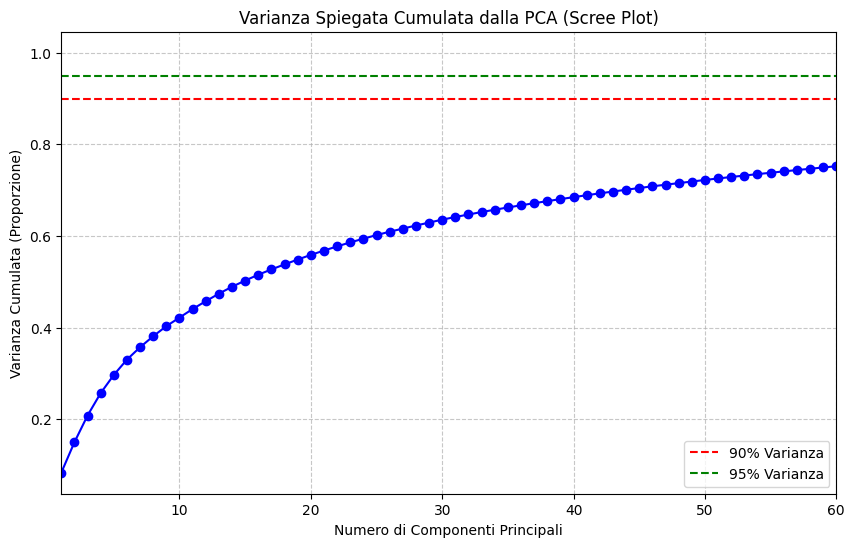

In [7]:
# 1. Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

# 2. Inizializza la PCA SENZA specificare il numero di componenti.
# In questo modo calcolerà tutte le 512 componenti (o min(n_samples, n_features)).
pca = PCA()
pca.fit(X_train_scaled)

# 3. Estrai la proporzione di varianza spiegata da ogni singola componente
# e calcola la somma cumulativa
varianza_singola = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_singola)

# 4. Creazione del Grafico (Scree Plot)
plt.figure(figsize=(10, 6))

# Plotta la curva della varianza cumulata
plt.plot(range(1, len(varianza_cumulata) + 1), varianza_cumulata, marker='o', linestyle='-', color='b')
plt.xlim(1, 60)

# Aggiungi linee di riferimento (es. per il 90% e il 95% della varianza)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')

# Estetica del grafico
plt.title('Varianza Spiegata Cumulata dalla PCA (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata (Proporzione)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

In [8]:
PCA_32 = PCA(n_components=32)
X_train_pca_32 = PCA_32.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 32 componenti: {PCA_32.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 32 componenti: 0.6469


In [9]:
PCA_16 = PCA(n_components=16)
X_train_pca_16 = PCA_16.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 16 componenti: {PCA_16.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 16 componenti: 0.5155


In [10]:
PCA_8 = PCA(n_components=8)
X_train_pca_8 = PCA_8.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 8 componenti: {PCA_8.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 8 componenti: 0.3812


In [11]:
PCA_4 = PCA(n_components=4)
X_train_pca_4 = PCA_4.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 4 componenti: {PCA_4.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 4 componenti: 0.2571


In [ ]:
sio.dump(PCA_32, f'{ASSETS_DIR}/seeds_11/pca_32.skops')
sio.dump(PCA_16, f'{ASSETS_DIR}/seeds_11/pca_16.skops')
sio.dump(PCA_8, f'{ASSETS_DIR}/seeds_11/pca_8.skops')
sio.dump(PCA_4, f'{ASSETS_DIR}/seeds_11/pca_4.skops')   
sio.dump(scaler, f'{ASSETS_DIR}/seeds_11/scaler.skops')

La root del progetto è: /home/kirjia/ProgettoQuantumBioetria/src
